# Modelado

En este notebook se entrena y se comparan modelos para decidir qué transacciones aprobar o bloquear, con el objetivo de **maximizar la ganancia** de la empresa.

## Datos y métrica de negocio

### Carga y split temporal

Se carga el dataset procesado y se divide respetando el orden cronológico en tres partes: train, validation y test.

In [2]:
import pandas as pd
import numpy as np

TARGET = "fraude"
df = pd.read_parquet("../data/processed/fraud_fe.parquet").sort_values("fecha")

# Cortes cronologicos: 60% train, 20% validacion, 20% test
corte_val, corte_test = df["fecha"].quantile([0.60, 0.80])

train = df[df["fecha"] < corte_val]
val = df[(df["fecha"] >= corte_val) & (df["fecha"] < corte_test)]
test = df[df["fecha"] >= corte_test]

for nombre, parte in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{nombre:5}: {parte.shape[0]:>6} filas,  fraude {parte[TARGET].mean():.4f} "
          f", {parte['fecha'].min().date()} -> {parte['fecha'].max().date()}")

Train:  90000 filas,  fraude 0.0511 , 2020-03-08 -> 2020-04-05
Val  :  30000 filas,  fraude 0.0536 , 2020-04-05 -> 2020-04-14
Test :  30000 filas,  fraude 0.0431 , 2020-04-14 -> 2020-04-21


### Métrica de negocio

La decisión del modelo es binaria: **aprobar** (0) o **bloquear** (1) una transacción. La ganancia se define como:

- Transacción **legítima aprobada** → se gana el 25% del monto.
- Transacción **fraudulenta aprobada** → se pierde el 100% del monto.
- Transacción **bloqueada** (sea fraude o no) → no genera ganancia ni pérdida.

Siendo esta la métrica que se busca maximizar.

In [3]:
def ganancia(y_true, y_pred, monto):
    """Ganancia total dado un vector de decisiones (0=aprobar, 1=bloquear)."""
    aprobadas = (y_pred == 0)
    ganancia_legitimas = 0.25 * monto[aprobadas & (y_true == 0)].sum()
    perdida_fraudes = monto[aprobadas & (y_true == 1)].sum()
    return ganancia_legitimas - perdida_fraudes

## Regresión logística

Se entrena un modelo simple e interpretable para tomar como baseline. La regresión logística necesita un preprocesamiento que se encapsula en un `Pipeline`:

- **Imputación** de nulos 
- **Estandarización** ya que es sensible a la escala.
- **One-hot** de la única categórica en texto, `g`.
- Se usa **`log_monto`** en vez de `monto` ya que al ser un modelo lineal sí se beneficia de corregir la asimetría.

Acá los indicadores de ausencia (`o_is_null`, etc.) sí aportan, pues como imputamos los nulos, el indicador conserva la información de que el dato faltaba.

### Definición y entrenamiento del pipeline

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# Features
features_log = [c for c in df.columns if c not in ["fecha", TARGET, "monto"]]
cat_cols = ["g"]
num_cols = [c for c in features_log if c not in cat_cols]

# Transformaciones
preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

modelo_log = Pipeline([
    ("prep", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
modelo_log.fit(train[features_log], train[TARGET])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['b','c','d',...,'o_is_null','b_is_null','d_is_null']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere n

### Evaluación en validación

Se obtienen métricas **independientes del umbral**, que son la comparación justa entre modelos.

In [5]:
proba_val_log = modelo_log.predict_proba(val[features_log])[:, 1]

pr_auc = average_precision_score(val[TARGET], proba_val_log)
roc_auc = roc_auc_score(val[TARGET], proba_val_log)
print(f"VAL  PR-AUC: {pr_auc:.4f}  |  ROC-AUC: {roc_auc:.4f}")

# Ganancia a umbral 0.5
y_val, monto_val = val[TARGET].values, val["monto"].values
decision = (proba_val_log >= 0.5).astype(int)
print(f"Ganancia val (umbral 0.5): {ganancia(y_val, decision, monto_val):,.2f}")
print(f"Referencia aprobar todo  : {ganancia(y_val, np.zeros_like(y_val), monto_val):,.2f}")

VAL  PR-AUC: 0.3447  |  ROC-AUC: 0.8429
Ganancia val (umbral 0.5): 176,614.12
Referencia aprobar todo  : 161,260.05


## Gradient boosting

Se entrenan dos modelos de boosting, HistGradientBoosting y LightGBM, para evaluar si este tipo de modelos se ajusta mejor al problema, ya que capturan las relaciones no lineales y no monótonas observadas en algunas variables.

A diferencia de la regresión logística, para árboles se usa **`monto`** en vez de `log_monto` ya que es redundante por ser una transformación monótona, y se conservan los `NaN` y la categórica `g` se
pasa a one-hot.

In [6]:
SEED = 42

# Features para arboles
features_arb = [c for c in df.columns if c not in ["fecha", TARGET, "log_monto"]]

# Transformacion
X_train_gb = pd.get_dummies(train[features_arb], columns=["g"])
X_val_gb = pd.get_dummies(val[features_arb], columns=["g"]).reindex(columns=X_train_gb.columns, fill_value=0)

### HistGradientBoosting

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

modelo_hgb = HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)
modelo_hgb.fit(X_train_gb, train[TARGET])

proba_val_hgb = modelo_hgb.predict_proba(X_val_gb)[:, 1]

### LightGBM

In [8]:
from lightgbm import LGBMClassifier

modelo_lgbm_base = LGBMClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1, verbose=-1)
modelo_lgbm_base.fit(X_train_gb, train[TARGET])

proba_val_lgbm_base = modelo_lgbm_base.predict_proba(X_val_gb)[:, 1]

### Evaluación y comparación con el baseline

In [9]:
comparacion = pd.DataFrame({
    "PR-AUC": [average_precision_score(val[TARGET], proba_val_log),
               average_precision_score(val[TARGET], proba_val_hgb),
               average_precision_score(val[TARGET], proba_val_lgbm_base)],
    "ROC-AUC": [roc_auc_score(val[TARGET], proba_val_log),
                roc_auc_score(val[TARGET], proba_val_hgb),
                roc_auc_score(val[TARGET], proba_val_lgbm_base)],
}, index=["Regresion logistica", "HistGradientBoosting", "LightGBM"]).round(4)
comparacion

,PR-AUC,ROC-AUC
Regresion logistica,0.3447,0.8429
HistGradientBoosting,0.4731,0.8895
LightGBM,0.4777,0.8884


**Análisis:** ambos modelos de boosting mejoran claramente a la regresión logística
(PR-AUC ~0.47 vs ~0.34), confirmando que la estructura no lineal de los datos justifica un modelo
más complejo. Entre ellos, HistGradientBoosting y LightGBM rinden casi igual sin tuneo. En la
sección siguiente ajustamos sus hiperparámetros para definir el modelo principal.

## Ajuste de hiperparámetros

Se ajustan los hiperparámetros con una búsqueda aleatoria. Para esta sección, se tomaron las siguientes decisiones clave para que el tuneo sea válido:
- Se usa **`TimeSeriesSplit`** en lugar de la validación cruzada por defecto debido a que esta respeta el orden temporal y en este caso nos importa el orden.
- La búsqueda se hace solo sobre los datos de train.
- Se usa `RandomizedSearchCV` para el modelo *LightGBM* ya que es más eficiente cuando el ajuste de parámetros es grande.
- Se optimiza el **PR-AUC**.

### LightGBM

In [10]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint, uniform

# Definicion de parametros
espacio = {
    "learning_rate": loguniform(0.02, 0.2),
    "num_leaves": randint(20, 80),
    "n_estimators": randint(200, 450),
    "min_child_samples": randint(20, 100),
    "subsample": uniform(0.7, 0.3),
    "subsample_freq": [1],
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_lambda": loguniform(1e-3, 10),
}

In [11]:
# Busqueda de parametros
busqueda_lgbm = RandomizedSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=SEED, n_jobs=1, verbose=-1),
    espacio, n_iter=10, scoring="average_precision",
    cv=TimeSeriesSplit(n_splits=3), random_state=SEED, n_jobs=-1,
)
busqueda_lgbm.fit(X_train_gb, train[TARGET])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x12021d160>, 'learning_rate': <scipy.stats....t 0x12021ccb0>, 'min_child_samples': <scipy.stats....t 0x12021cef0>, 'n_estimators': <scipy.stats....t 0x12021d130>, ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at t

In [12]:
# Mejores parametros
modelo_lgbm = busqueda_lgbm.best_estimator_
proba_val_lgbm = modelo_lgbm.predict_proba(X_val_gb)[:, 1]
print("Mejores hiperparametros:")
for k, v in busqueda_lgbm.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nPR-AUC (CV temporal): {busqueda_lgbm.best_score_:.4f}")

Mejores hiperparametros:
  colsample_bytree: 0.7511572371061874
  learning_rate: 0.023231731978492907
  min_child_samples: 23
  n_estimators: 288
  num_leaves: 79
  reg_lambda: 0.17912362571043663
  subsample: 0.8156249507619748
  subsample_freq: 1

PR-AUC (CV temporal): 0.4470


### HistGradientBoosting ajustado
También se ajustan los parámetros del HistGradientBoosting con `GridSearchCV` para ver si se logra alguna mejora.

In [13]:
# Definicion de parametros
grid_hist = {
    "learning_rate": [0.05, 0.1],
    "max_leaf_nodes": [31, 63],
    "min_samples_leaf": [20, 50],
}

In [14]:
# Busqueda de parametros
busqueda_hist = GridSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
    grid_hist, scoring="average_precision", cv=TimeSeriesSplit(n_splits=3), n_jobs=-1,
)
busqueda_hist.fit(X_train_gb, train[TARGET])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_leaf_nodes': [31, 63], 'min_samples_leaf': [20, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [15]:
# Mejores parametros
modelo_hist_tuned = busqueda_hist.best_estimator_
proba_val_hist_tuned = modelo_hist_tuned.predict_proba(X_val_gb)[:, 1]
print("Mejores hiperparametros:", busqueda_hist.best_params_)
print(f"PR-AUC (CV temporal): {busqueda_hist.best_score_:.4f}")

Mejores hiperparametros: {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'min_samples_leaf': 50}
PR-AUC (CV temporal): 0.4365


## Comparación de modelos en validación
Se comparan los 5 modelos definidos para determinar cuál de ellos representa el mejor ajuste de los datos hasta el momento.

In [16]:
comparacion_full = pd.DataFrame({
    "PR-AUC": [average_precision_score(val[TARGET], proba_val_log),
               average_precision_score(val[TARGET], proba_val_hgb),
               average_precision_score(val[TARGET], proba_val_hist_tuned),
               average_precision_score(val[TARGET], proba_val_lgbm_base),
               average_precision_score(val[TARGET], proba_val_lgbm)],
    "ROC-AUC": [roc_auc_score(val[TARGET], proba_val_log),
                roc_auc_score(val[TARGET], proba_val_hgb),
                roc_auc_score(val[TARGET], proba_val_hist_tuned),
                roc_auc_score(val[TARGET], proba_val_lgbm_base),
                roc_auc_score(val[TARGET], proba_val_lgbm)],
}, index=["Regresion logistica", "HistGB sin tuneo", "HistGB ajustado",
          "LightGBM sin tuneo", "LightGBM ajustado"]).round(4)
comparacion_full

,PR-AUC,ROC-AUC
Regresion logistica,0.3447,0.8429
HistGB sin tuneo,0.4731,0.8895
HistGB ajustado,0.4745,0.8897
LightGBM sin tuneo,0.4777,0.8884
LightGBM ajustado,0.4830,0.8899


**Análisis:** de los resultados anteriores se derivan dos conclusiones esencialmente:

1. El ajuste del HistGB no mostró ninguna mejora. Esto se puede dar debido a que sus valores por defecto ya estaban cerca del óptimo para estos datos.
2. El modelo LightGBM ajustado y HistGB ajustado son sumamente equivalentes, mostrando únicamente una diferencia mínima en PR-AUC, y un ROC-AUC casi idéntico.

En este sentido, se decide continuar usando **LightGBM ajustado** como modelo principal debido a su ligera ventaja en la métrica PR-AUC y a que soporta variables categóricas de forma nativa. Sin embargo, se demostró que **HistGradientBoosting** es una alternativa también válida e implica una dependencia menos.

## Selección del umbral por ganancia

La decisión de aprobar o bloquear requiere fijar un umbral sobre el score de fraude del modelo. Para seleccionarlo, se barren distintos valores del umbral y se elige el que **maximiza la ganancia** sobre el conjunto de validación, lo cual ptimiza directamente la métrica de negocio.

In [17]:
y_val, monto_val = val[TARGET].values, val["monto"].values
umbrales = np.linspace(0.01, 0.99, 99)

# Ganancia en validacion para cada umbral
ganancias = np.array([ganancia(y_val, (proba_val_lgbm >= u).astype(int), monto_val) for u in umbrales])
umbral_optimo = umbrales[ganancias.argmax()]

print(f"Umbral optimo (validacion): {umbral_optimo:.2f}  ->  ganancia {ganancias.max():,.0f}")

Umbral optimo (validacion): 0.73  ->  ganancia 208,606


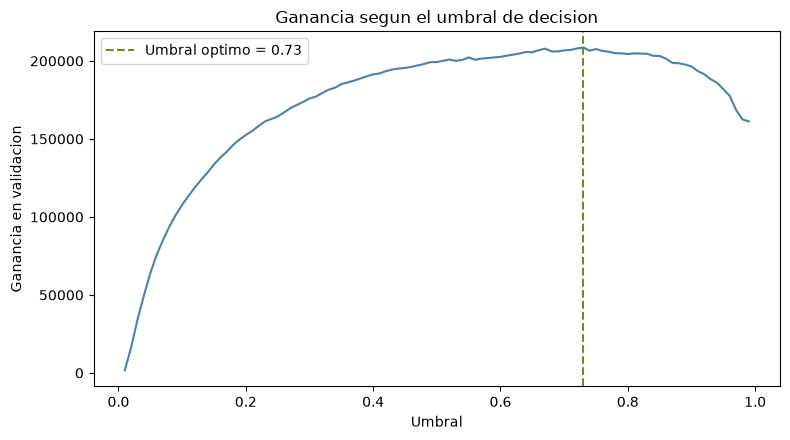

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(umbrales, ganancias, color="steelblue")
ax.axvline(umbral_optimo, color="olivedrab", ls="--", label=f"Umbral optimo = {umbral_optimo:.2f}")
ax.set_xlabel("Umbral"); ax.set_ylabel("Ganancia en validacion")
ax.set_title("Ganancia segun el umbral de decision"); ax.legend()
plt.tight_layout(); plt.show()

**Análisis:** el barrido muestra una ganancia claramente superior a la de "aprobar todo" en un rango amplio de umbrales, con un máximo bien definido. Se adopta el modelo (LightGBM ajustado) junto con ese umbral óptimo.

## Evaluación final en test

Se evalua el modelo (LightGBM ajustado) con el umbral elegido sobre el set de **test**.

### Métrica de negocio en test

In [19]:
# one-hot de test alineado a las columnas de entrenamiento
X_test_gb = pd.get_dummies(test[features_arb], columns=["g"]).reindex(columns=X_train_gb.columns, fill_value=0)

proba_test = modelo_lgbm.predict_proba(X_test_gb)[:, 1]
decision_test = (proba_test >= umbral_optimo).astype(int)

y_test, monto_test = test[TARGET].values, test["monto"].values

# Ganancia del modelo y escenarios de referencia
g_modelo = ganancia(y_test, decision_test, monto_test)
g_aprobar = ganancia(y_test, np.zeros_like(y_test), monto_test)
g_oraculo = ganancia(y_test, y_test, monto_test)

print(f"Ganancia del modelo        : {g_modelo:,.0f}")
print(f"Referencia 'aprobar todo'  : {g_aprobar:,.0f}")
print(f"Oraculo (decision perfecta): {g_oraculo:,.0f}")
print(f"\nRecuperado vs 'aprobar todo': {g_modelo - g_aprobar:,.0f}")
print(f"% capturado por el modelo vs oraculo: {100 * g_modelo / g_oraculo:.1f}%")

Ganancia del modelo        : 232,731
Referencia 'aprobar todo'  : 193,686
Oraculo (decision perfecta): 293,510

Recuperado vs 'aprobar todo': 39,046
% capturado por el modelo vs oraculo: 79.3%


**Análisis:** el modelo captura cerca del **80% de la ganancia máxima teórica** y mejora de forma clara el escenario de "aprobar todo", recuperando decenas de miles que de otro modo se perderían por fraude.

### Métricas de clasificación en test

In [20]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score, confusion_matrix

print(f"PR-AUC : {average_precision_score(y_test, proba_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"Precision: {precision_score(y_test, decision_test):.3f}  |  Recall: {recall_score(y_test, decision_test):.3f}")

cm = confusion_matrix(y_test, decision_test)
pd.DataFrame(cm, index=["Real legitima", "Real fraude"],
            columns=["Aprobada", "Bloqueada"])

PR-AUC : 0.4250
ROC-AUC: 0.8830
Precision: 0.348  |  Recall: 0.526


,Aprobada,Bloqueada
Real legitima,27435,1273
Real fraude,613,679


**Análisis:** con el umbral elegido, el modelo bloquea una porción relevante de los fraudes a costa de bloquear algunas transacciones legítimas. Sin embargo, este punto de operación no se eligió para optimizar precision/recall, sino la **ganancia**, dado que perder el 100% de un fraude pesa mucho más que dejar de ganar el 25% de una transacción legítima.